# Product Review Sentiment Classifier

Classifies a product/business review's text as **positive**, **negative**, or **neutral**.

- **Data:** [Yelp Review Full](https://huggingface.co/datasets/Yelp/yelp_review_full) (real, public, 1–5 star reviews)
- **Label mapping:** 1–2★ → negative, 3★ → neutral, 4–5★ → positive
- **Approach:** TF-IDF vectorization (unigrams + bigrams) + a linear Support Vector Machine
- **This notebook runs top to bottom** and reproduces the reported metrics exactly (fixed random seed).


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 2. Load the raw data

Reviews come from the [Yelp Review Full](https://huggingface.co/datasets/Yelp/yelp_review_full) dataset (test split). Each row has a `label` (0–4, corresponding to 1–5 stars) and the review `text`. The cell below downloads the raw parquet file the first time this notebook is run (it isn't committed to the repo — see `.gitignore`), so this runs top to bottom on a fresh clone.


In [2]:
import os
import requests

DATA_PATH = 'data_raw/yelp_test.parquet'
DATA_URL = (
    'https://huggingface.co/datasets/Yelp/yelp_review_full/resolve/'
    'refs%2Fconvert%2Fparquet/yelp_review_full/test/0000.parquet'
)

os.makedirs('data_raw', exist_ok=True)
if not os.path.exists(DATA_PATH):
    print("Downloading dataset (~23MB)...")
    response = requests.get(DATA_URL, timeout=60)
    response.raise_for_status()
    with open(DATA_PATH, 'wb') as f:
        f.write(response.content)

raw = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(raw):,} reviews")
raw['label'].value_counts().sort_index()


Loaded 50,000 reviews


label
0    10000
1    10000
2    10000
3    10000
4    10000
Name: count, dtype: int64

## 3. Map star ratings to 3-class sentiment

- Labels 0–1 (1–2 stars) → `negative`
- Label 2 (3 stars) → `neutral`
- Labels 3–4 (4–5 stars) → `positive`

To keep training fast and the class balance clean, we take a **stratified sample of 15,000 reviews** (5,000 per sentiment class) from the full 50,000-row set.


In [3]:
def to_sentiment(star_label: int) -> str:
    if star_label <= 1:
        return 'negative'
    if star_label == 2:
        return 'neutral'
    return 'positive'

raw['sentiment'] = raw['label'].apply(to_sentiment)

SAMPLE_PER_CLASS = 5000
df = pd.concat([
    group.sample(n=SAMPLE_PER_CLASS, random_state=RANDOM_SEED)
    for _, group in raw.groupby('sentiment')
]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Working set: {len(df):,} reviews")
df['sentiment'].value_counts()


Working set: 15,000 reviews


sentiment
positive    5000
neutral     5000
negative    5000
Name: count, dtype: int64

## 4. Train / test split (80 / 20, stratified)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['sentiment'],
    test_size=0.2, random_state=RANDOM_SEED, stratify=df['sentiment'],
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")


Train: 12,000  |  Test: 3,000


## 5. Preprocessing + model

**Preprocessing** is handled entirely by `TfidfVectorizer`:
- lowercasing
- English stopword removal
- unigrams + bigrams (`ngram_range=(1, 2)`), so short negations like *"not good"* are captured
  as a single feature instead of being lost
- vocabulary capped at 30,000 terms, terms appearing in fewer than 2 documents are dropped

**Model:** a linear Support Vector Machine (`LinearSVC`). Linear SVMs are a standard, strong
baseline for high-dimensional sparse text features like TF-IDF, and train in seconds on this
dataset size.


In [5]:
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        max_features=30_000,
        min_df=2,
    )),
    ('clf', LinearSVC(random_state=RANDOM_SEED, C=1.0)),
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['negative','neutral','positive']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",30000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If

## 6. Evaluate on the held-out test set

In [6]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")
print()
print(classification_report(y_test, y_pred, digits=3))


Accuracy: 67.27%

              precision    recall  f1-score   support

    negative      0.701     0.723     0.712      1000
     neutral      0.578     0.546     0.562      1000
    positive      0.731     0.749     0.740      1000

    accuracy                          0.673      3000
   macro avg      0.670     0.673     0.671      3000
weighted avg      0.670     0.673     0.671      3000



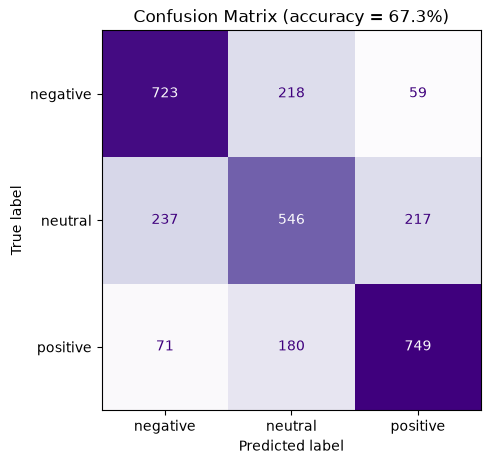

In [7]:
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title(f'Confusion Matrix (accuracy = {acc:.1%})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


## 7. Binary evaluation (positive vs negative only)

Many sentiment analysis benchmarks report accuracy on the **binary** (positive/negative) version of the problem, since excluding the inherently ambiguous neutral class is a common, easier comparison point — this is *not* the same model as above; it's a separate model trained and evaluated only on the positive/negative subset of the same sampled data, so the two numbers are not directly comparable but both are worth reporting.


In [8]:
binary_df = df[df['sentiment'] != 'neutral'].reset_index(drop=True)
print(f"Binary working set: {len(binary_df):,} reviews")
binary_df['sentiment'].value_counts()


Binary working set: 10,000 reviews


sentiment
positive    5000
negative    5000
Name: count, dtype: int64

In [9]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    binary_df['text'], binary_df['sentiment'],
    test_size=0.2, random_state=RANDOM_SEED, stratify=binary_df['sentiment'],
)
print(f"Train: {len(Xb_train):,}  |  Test: {len(Xb_test):,}")

binary_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        max_features=30_000,
        min_df=2,
    )),
    ('clf', LinearSVC(random_state=RANDOM_SEED, C=1.0)),
])
binary_model.fit(Xb_train, yb_train)

yb_pred = binary_model.predict(Xb_test)
binary_acc = accuracy_score(yb_test, yb_pred)
print(f"Binary accuracy: {binary_acc:.2%}")
print()
print(classification_report(yb_test, yb_pred, digits=3))


Train: 8,000  |  Test: 2,000


Binary accuracy: 89.45%

              precision    recall  f1-score   support

    negative      0.900     0.888     0.894      1000
    positive      0.889     0.901     0.895      1000

    accuracy                          0.894      2000
   macro avg      0.895     0.895     0.894      2000
weighted avg      0.895     0.894     0.894      2000



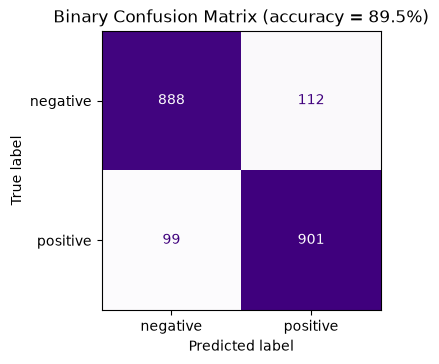

In [10]:
binary_labels = ['negative', 'positive']
cm_b = confusion_matrix(yb_test, yb_pred, labels=binary_labels)
disp_b = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=binary_labels)
fig, ax = plt.subplots(figsize=(4, 4))
disp_b.plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title(f'Binary Confusion Matrix (accuracy = {binary_acc:.1%})')
plt.tight_layout()
plt.savefig('confusion_matrix_binary.png', dpi=150)
plt.show()


## 8. Try it on new sentences

A quick sanity check on hand-written examples the model has never seen.


In [11]:
samples = [
    "Absolutely loved this place, the staff were incredible and the food was perfect.",
    "Terrible experience, will never come back. Rude staff and cold food.",
    "It was fine. Nothing special, but nothing wrong with it either.",
    "The product broke after two days. Complete waste of money.",
    "Pretty good overall, though the price is a bit high for what you get.",
]

for text, pred in zip(samples, model.predict(samples)):
    print(f"[{pred:>8}]  {text}")


[positive]  Absolutely loved this place, the staff were incredible and the food was perfect.
[negative]  Terrible experience, will never come back. Rude staff and cold food.
[ neutral]  It was fine. Nothing special, but nothing wrong with it either.
[negative]  The product broke after two days. Complete waste of money.
[ neutral]  Pretty good overall, though the price is a bit high for what you get.


## 9. Save the trained model

In [12]:
joblib.dump(model, 'sentiment_model.joblib')
print("Saved to sentiment_model.joblib")


Saved to sentiment_model.joblib
